# Wound Segmentation

## Configuration
### Imports


In [ ]:
!pip install torchsummary opencv-python


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as T
import zipfile
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset
import copy
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Paths


In [ ]:
# basepath und co werden hier definiert
base_path = r"/content/drive/MyDrive/Masterarbeit/Segmentation_Datasets/seed_2026"
train_images_path = os.path.join(base_path, "train_images_aug")
train_masks_path = os.path.join(base_path, "train_masks_aug")
val_images_path = os.path.join(base_path, "val_images")
val_masks_path = os.path.join(base_path, "val_masks")
test_images_path = os.path.join(base_path, "test_images")
test_masks_path = os.path.join(base_path, "test_masks")
excel_path = os.path.join(base_path, "correspondence_table.xlsx")

paths = {
    "Train Images": train_images_path,
    "Train Masks": train_masks_path,
    "Val Images": val_images_path,
    "Val Masks": val_masks_path,
    "Test Images": test_images_path,
    "Test Masks": test_masks_path,
}




## Train Model

In [ ]:
IMG_SIZE = (256, 256)

# Converting into Tensors
img_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

mask_transform = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor()
])

def load_images_and_masks(img_dir, mask_dir):
    images, masks = [], []
    filenames = sorted(os.listdir(img_dir))

    for fname in filenames:
        img_path = os.path.join(img_dir, fname)

        # Get base name without extension
        basename, _ = os.path.splitext(fname)

        # --- Load image ---
        img = Image.open(img_path).convert("RGB")
        img = img_transform(img)   # shape: [3, H, W]

        # --- Load mask (grayscale) ---
        # Check for both .png and .jpg extensions for the mask
        mask_path_png = os.path.join(mask_dir, basename + ".png")
        mask_path_jpg = os.path.join(mask_dir, basename + ".jpg")

        mask = None
        if os.path.exists(mask_path_png):
            mask = Image.open(mask_path_png).convert("L")
        elif os.path.exists(mask_path_jpg):
            mask = Image.open(mask_path_jpg).convert("L")
        else:
            raise FileNotFoundError(f"No mask found for image {fname} at {mask_path_png} or {mask_path_jpg}")

        mask = mask_transform(mask)    # shape: [1, H, W]

        # --- Binarize mask like your TensorFlow version ---
        mask = (mask > 0.5).float()

        images.append(img)
        masks.append(mask)

    # Stack into tensors
    return torch.stack(images), torch.stack(masks)

X_train, Y_train = load_images_and_masks(paths.get("Train Images"), paths.get("Train Masks"))
X_val, Y_val = load_images_and_masks(paths.get("Val Images"), paths.get("Val Masks"))
# # Train/validation split
# X_train, X_val, Y_train, Y_val = train_test_split(
#     X, Y, test_size=0.15 , random_state=42
# )

print("Data loaded and preprocessed (PyTorch)")
print(f"Train samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")
print(f"Image tensor shape: {X_train[0].shape}")
print(f"Mask tensor shape:  {Y_train[0].shape}")

Data loaded and preprocessed (PyTorch)
Train samples: 3870, Validation samples: 714
Image tensor shape: torch.Size([3, 256, 256])
Mask tensor shape:  torch.Size([1, 256, 256])


## Define U-Net Architecture

In [ ]:
# ----------------------- Helpers for Loss and Metrics -----------------------
# Dice Loss (can be used as part of a combined loss function)
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)

        return 1 - dice

# Combined Loss: BCE + Dice
class CombinedLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        dice_loss = self.dice(inputs, targets)
        return bce_loss + dice_loss

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # logits: (N,1,H,W)
        # targets: (N,1,H,W) in {0,1}

        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        dice_loss = 1.0 - dice.mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, preds, targets):
        """
        preds:   (B,1,H,W) sigmoid output in [0,1]
        targets: (B,1,H,W) binary {0,1}
        """
        preds = preds.view(-1)
        targets = targets.view(-1)

        TP = (preds * targets).sum()
        FP = ((1 - targets) * preds).sum()
        FN = (targets * (1 - preds)).sum()

        tversky = (TP + self.smooth) / (
            TP + self.alpha * FP + self.beta * FN + self.smooth
        )

        return 1 - tversky

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # logits: (N,1,H,W)
        # targets: (N,1,H,W) in {0,1}

        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        dice_loss = 1.0 - dice.mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

In [ ]:
# Metrics functions (per batch)
def iou_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum() - intersection + 1e-7
    return (intersection / union).item()

def dice_coef(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    intersection = (2.0 * (y_true * y_pred).sum())
    denom = y_true.sum() + y_pred.sum() + 1e-7
    return (intersection / denom).item()


In [ ]:
class DoubleConv(nn.Module):
    """
    Block: Conv2d -> ReLU -> Conv2d -> ReLU
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models.feature_extraction import create_feature_extractor


# ============================================================
# Basic blocks
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up(x)


class AttentionBlock(nn.Module):
    def __init__(self, in_ch_x, in_ch_g, inter_ch):
        super().__init__()
        self.W_x = nn.Sequential(
            nn.Conv2d(in_ch_x, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_g = nn.Sequential(
            nn.Conv2d(in_ch_g, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        if g1.shape[-2:] != x1.shape[-2:]:
            g1 = F.interpolate(g1, size=x1.shape[-2:], mode="bilinear", align_corners=False)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


# ============================================================
# Decoder block
# ============================================================

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.2):
        super().__init__()

        self.up = UpConv(in_ch, out_ch)
        self.att = AttentionBlock(
            in_ch_x=skip_ch,
            in_ch_g=out_ch,
            inter_ch=max(out_ch // 2, 8),
        )
        self.conv = nn.Sequential(
            ConvBlock(out_ch + skip_ch, out_ch),
            nn.Dropout2d(dropout),
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        skip = self.att(skip, x)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


# ============================================================
# Attention U-Net with EfficientNet-B0 Encoder
# ============================================================

class AttentionUNetEfficientNetB0(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 1,
        pretrained: bool = True,
        freeze_backbone: bool = False,
    ):
        super().__init__()

        # ---------------- Encoder ----------------
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        backbone = models.efficientnet_b0(weights=weights)

        if in_channels != 3:
            first = backbone.features[0][0]
            backbone.features[0][0] = nn.Conv2d(
                in_channels=in_channels,
                out_channels=first.out_channels,
                kernel_size=first.kernel_size,
                stride=first.stride,
                padding=first.padding,
                bias=False,
            )

        if freeze_backbone:
            for p in backbone.parameters():
                p.requires_grad = False

        return_nodes = {
            "features.0": "x0",  # H/2, 32
            "features.2": "x1",  # H/4, 24
            "features.3": "x2",  # H/8, 40
            "features.5": "x3",  # H/16, 112
            "features.8": "x4",  # H/32, 1280
        }

        self.encoder = create_feature_extractor(backbone, return_nodes=return_nodes)

        # ---------------- Decoder ----------------
        self.decoder = nn.ModuleDict({
            "d4": DecoderBlock(1280, 112, 112),
            "d3": DecoderBlock(112, 40, 40),
            "d2": DecoderBlock(40, 24, 24),
            "d1": DecoderBlock(24, 32, 32),
        })

        # ---------------- Output ----------------
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        feats = self.encoder(x)

        x0 = feats["x0"]
        x1 = feats["x1"]
        x2 = feats["x2"]
        x3 = feats["x3"]
        x4 = feats["x4"]

        d4 = self.decoder["d4"](x4, x3)
        d3 = self.decoder["d3"](d4, x2)
        d2 = self.decoder["d2"](d3, x1)
        d1 = self.decoder["d1"](d2, x0)

        out = self.out_conv(d1)

        if out.shape[-2:] != x.shape[-2:]:
            out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)

        return out  # logits


## Training

### Params

In [ ]:
IN_CHANNELS = 3
OUT_CHANNELS = 1 # for binary segmentation
LR = 1e-4 # learning rate
BATCH_SIZE = 12
EARLYSTOPPING_PATIENCE = 10
NUM_EPOCHS = 50


### MLflow Tracking

In diesem Abschnitt werden Hyperparameter, Metriken und Artefakte pro Run mit MLflow protokolliert. Du kannst damit Runs vergleichen, ohne manuell Notizen zu machen.

In [ ]:
# MLflow Setup
!pip -q install mlflow

import mlflow
import mlflow.pytorch

drive_mlruns_path = "/content/drive/MyDrive/mlruns"
os.makedirs(drive_mlruns_path, exist_ok=True)

# Speichere Runs in Google Drive
mlflow.set_tracking_uri(f"file:{drive_mlruns_path}")

# Optional: Experiment Name anpassen
MLFLOW_EXPERIMENT_NAME = "wound_segmentation_unet"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.6/810.6 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 24.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///content/drive/MyDrive/mlruns/905175461730057483', creation_time=1767559018797, experiment_id='905175461730057483', last_update_time=1767559018797, lifecycle_stage='active', name='wound_segmentation_unet', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [ ]:
# Metrics functions (per batch)
def iou_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum() - intersection + 1e-7
    return (intersection / union).item()

def dice_coef(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    intersection = (2.0 * (y_true * y_pred).sum())
    denom = y_true.sum() + y_pred.sum() + 1e-7
    return (intersection / denom).item()


In [ ]:
    # ----------------------- Prepare DataLoaders -----------------------
    import torch.optim.lr_scheduler as lr_scheduler
    import time
    SEED = 42

    g = torch.Generator()
    g.manual_seed(SEED)

    train_dataset = TensorDataset(X_train, Y_train)
    val_dataset = TensorDataset(X_val, Y_val)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # Changed shuffle to False for determinism

    # ----------------------- Device -----------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # ----------------------- Model, Optimizer, Loss -----------------------

    model = AttentionUNetEfficientNetB0(
            in_channels=IN_CHANNELS,
            out_channels=OUT_CHANNELS,
            pretrained=True,
            freeze_backbone=False,
    ).to(device)




    optimizer = torch.optim.AdamW(
        [
            {"params": model.encoder.parameters(), "lr": LR * 0.1, "weight_decay": 1e-6}, # Kaum Decay für Pretrained
            {"params": model.decoder.parameters(), "lr": LR, "weight_decay": 1e-4},       # Normales Decay für neuen Decoder
        ],
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = BCEDiceLoss() # Use the combined loss function

    # Learning Rate Scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max', # Monitor a metric that should be maximized (like Dice or IoU)
        factor=0.5, # Factor by which the learning rate will be reduced
        patience=4, # Number of epochs with no improvement after which learning rate will be reduced
        min_lr=1e-6 # Minimum learning rate
    )

    # ----------------------- Early Stopping -----------------------
    class EarlyStopping:
        def __init__(self, patience=5, restore_best_weights=True):
            self.patience = patience
            self.restore_best_weights = restore_best_weights
            self.best_score = float("-inf")
            self.best_state = None
            self.counter = 0
            self.early_stop = False
            self.best_epoch = 0

        def __call__(self, score, model, epoch):
            if score > self.best_score:
                self.best_score = score
                self.counter = 0
                self.best_epoch = epoch
                if self.restore_best_weights:
                    self.best_state = copy.deepcopy(model.state_dict())
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True

        def restore(self, model):
            if self.restore_best_weights and self.best_state is not None:
                model.load_state_dict(self.best_state)

    early_stopping = EarlyStopping(patience=EARLYSTOPPING_PATIENCE, restore_best_weights=True)

    # ----------------------- MLflow Run -----------------------
    run_name = f"bs{BATCH_SIZE}_lr{LR}_{int(time.time())}"

    history = {"loss": [], "val_loss": [], "val_dice": [], "val_iou": []}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(
            {
                "in_channels": IN_CHANNELS,
                "out_channels": OUT_CHANNELS,
                "lr": LR,
                "batch_size": BATCH_SIZE,
                "epochs": NUM_EPOCHS,
                "earlystopping_patience": EARLYSTOPPING_PATIENCE,
                "optimizer": "AdamW", # Updated optimizer name
                "weight_decay": 1e-5, # Added weight decay
                "loss": "BCE+DiceLoss", # Update loss name in mlflow
                "threshold": 0.5,
                "scheduler": "ReduceLROnPlateau",
                "scheduler_mode": "max",
                "scheduler_factor": 0.5,
                "scheduler_patience": 4,
                "scheduler_min_lr": 1e-6
            }
        )

        # ----------------------- Training Loop -----------------------
        for epoch in range(NUM_EPOCHS):
            model.train()
            train_loss_sum = 0.0

            for imgs, masks in train_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)

                optimizer.zero_grad()
                logits = model(imgs)
                loss = criterion(logits, masks)
                loss.backward()
                optimizer.step()

                train_loss_sum += loss.item()

            train_loss = train_loss_sum / len(train_loader)

            model.eval()
            val_loss_sum = 0.0
            val_dice_sum = 0.0
            val_iou_sum = 0.0

            with torch.no_grad():
                for imgs, masks in val_loader:
                    imgs = imgs.to(device)
                    masks = masks.to(device)

                    logits = model(imgs)
                    loss = criterion(logits, masks)

                    probs = torch.sigmoid(logits)

                    val_loss_sum += loss.item()
                    val_dice_sum += dice_coef(masks, probs)
                    val_iou_sum += iou_score(masks, probs)

            val_loss = val_loss_sum / len(val_loader)
            val_dice = val_dice_sum / len(val_loader)
            val_iou = val_iou_sum / len(val_loader)

            scheduler.step(val_dice)
            early_stopping(val_dice, model, epoch + 1)

            history["loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_dice"].append(val_dice)
            history["val_iou"].append(val_iou)

            mlflow.log_metric("train_loss", train_loss, step=epoch + 1)
            mlflow.log_metric("val_loss", val_loss, step=epoch + 1)
            mlflow.log_metric("val_dice", val_dice, step=epoch + 1)
            mlflow.log_metric("val_iou", val_iou, step=epoch + 1)
            mlflow.log_metric("lr", optimizer.param_groups[0]["lr"], step=epoch + 1)

            print(
                f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                f"loss {train_loss:.4f} | "
                f"val_loss {val_loss:.4f} | "
                f"val_dice {val_dice:.4f} | "
                f"val_iou {val_iou:.4f}"
            )

            if early_stopping.early_stop:
                print(f"Early stopping at epoch {epoch+1}")
                break

        early_stopping.restore(model)

        # ========================================================
        # Save artifacts
        # ========================================================

        output_dir = "./eval_seg"
        os.makedirs(output_dir, exist_ok=True)

        model_path = os.path.join(output_dir, "wound_segmentation_model_best.pth")
        torch.save(model.state_dict(), model_path)

        hist_df = pd.DataFrame(
            {
                "epoch": range(1, len(history["loss"]) + 1),
                "train_loss": history["loss"],
                "val_loss": history["val_loss"],
                "val_dice": history["val_dice"],
                "val_iou": history["val_iou"],
            }
        )

        hist_path = os.path.join(output_dir, "history.csv")
        hist_df.to_csv(hist_path, index=False)

        mlflow.log_artifact(model_path)
        mlflow.log_artifact(hist_path)
        mlflow.pytorch.log_model(model, artifact_path="model")

    print("Training complete.")

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 230MB/s]


Epoch 1/50 | loss 0.7147 | val_loss 0.6214 | val_dice 0.7662 | val_iou 0.6267
Epoch 2/50 | loss 0.5887 | val_loss 0.5598 | val_dice 0.7935 | val_iou 0.6630
Epoch 3/50 | loss 0.5302 | val_loss 0.4977 | val_dice 0.8341 | val_iou 0.7197
Epoch 4/50 | loss 0.4784 | val_loss 0.4530 | val_dice 0.8163 | val_iou 0.6959
Epoch 5/50 | loss 0.4319 | val_loss 0.4188 | val_dice 0.8144 | val_iou 0.6932
Epoch 6/50 | loss 0.3860 | val_loss 0.3696 | val_dice 0.8552 | val_iou 0.7515
Epoch 7/50 | loss 0.3416 | val_loss 0.3312 | val_dice 0.8450 | val_iou 0.7369
Epoch 8/50 | loss 0.2993 | val_loss 0.2870 | val_dice 0.8593 | val_iou 0.7578
Epoch 9/50 | loss 0.2568 | val_loss 0.2433 | val_dice 0.8685 | val_iou 0.7714
Epoch 10/50 | loss 0.2182 | val_loss 0.2212 | val_dice 0.8622 | val_iou 0.7625
Epoch 11/50 | loss 0.1843 | val_loss 0.1829 | val_dice 0.8752 | val_iou 0.7820
Epoch 12/50 | loss 0.1559 | val_loss 0.1591 | val_dice 0.8735 | val_iou 0.7798
Epoch 13/50 | loss 0.1334 | val_loss 0.1450 | val_dice 0.8784

2026/02/24 18:34:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 18:34:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/24 18:34:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/24 18:34:22 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+c

Training complete.


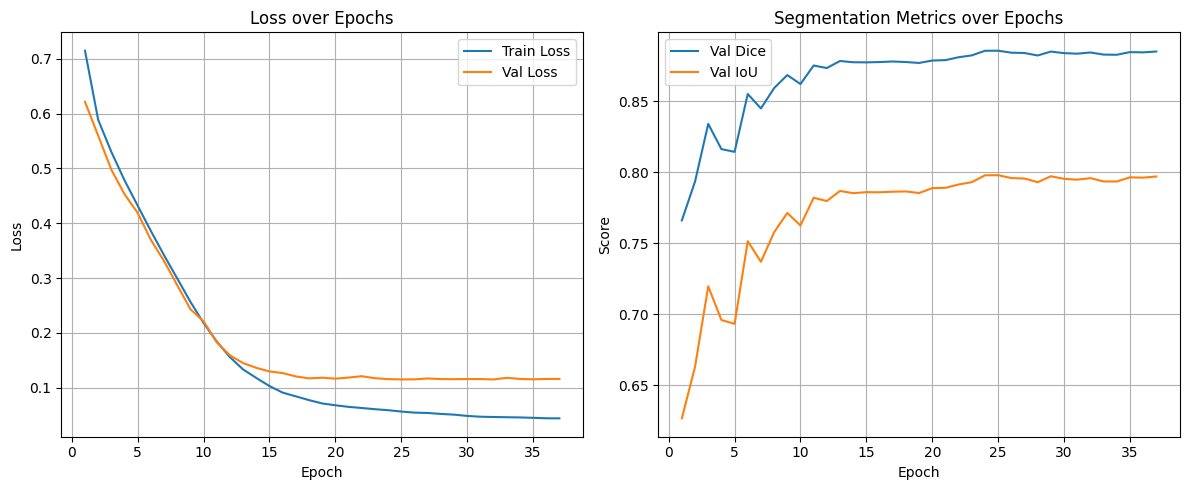

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history["loss"]) + 1))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.plot(epochs, history["val_iou"], label="Val IoU")
plt.title("Segmentation Metrics over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


<Figure size 600x600 with 0 Axes>

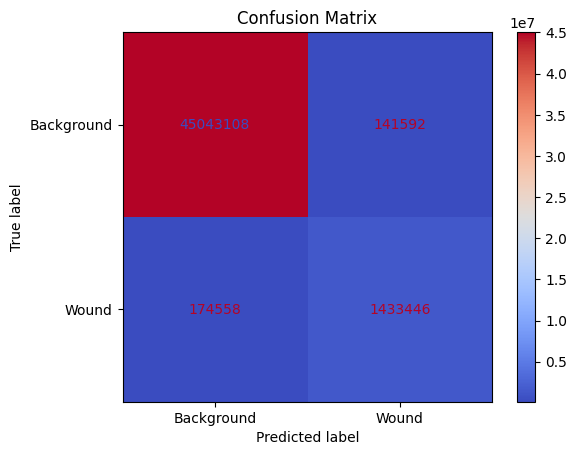

Classification Report:

              precision    recall  f1-score   support

  Background       1.00      1.00      1.00  45184700
       Wound       0.91      0.89      0.90   1608004

    accuracy                           0.99  46792704
   macro avg       0.95      0.94      0.95  46792704
weighted avg       0.99      0.99      0.99  46792704



In [ ]:

# Ensure eval mode
model.eval()

# For using Cuda if moving to volab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Initialize lists to store true and predicted masks for confusion matrix
all_y_true_flat = []
all_y_pred_flat = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)          # shape [B, 1, H, W]

        # Move to CPU and convert to numpy
        preds_np_batch = preds.cpu().numpy()           # float values in [0,1]
        preds_binary_batch = (preds_np_batch > 0.5).astype(np.uint8)

        # Ground truth as numpy
        y_true_np_batch = masks.cpu().numpy().astype(np.uint8)   # shape [B, 1, H, W]

        # Flatten for confusion matrix and report
        all_y_true_flat.extend(y_true_np_batch.flatten())
        all_y_pred_flat.extend(preds_binary_batch.flatten())

# Concatenate all flattened true and predicted values
y_true = np.array(all_y_true_flat)
y_pred = np.array(all_y_pred_flat)

cm = confusion_matrix(y_true, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=["Background", "Wound"])

plt.figure(figsize=(6, 6))
cmd.plot(cmap='coolwarm', values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

report = classification_report(y_true, y_pred, target_names=["Background", "Wound"])
print("Classification Report:\n")
print(report)



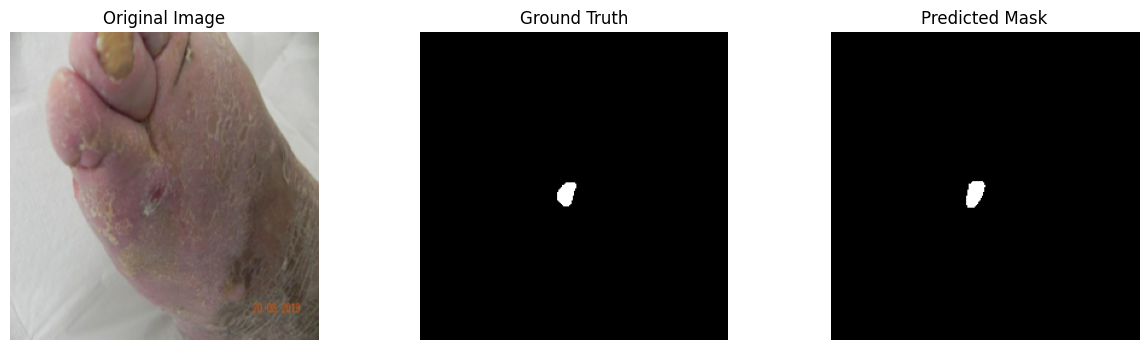

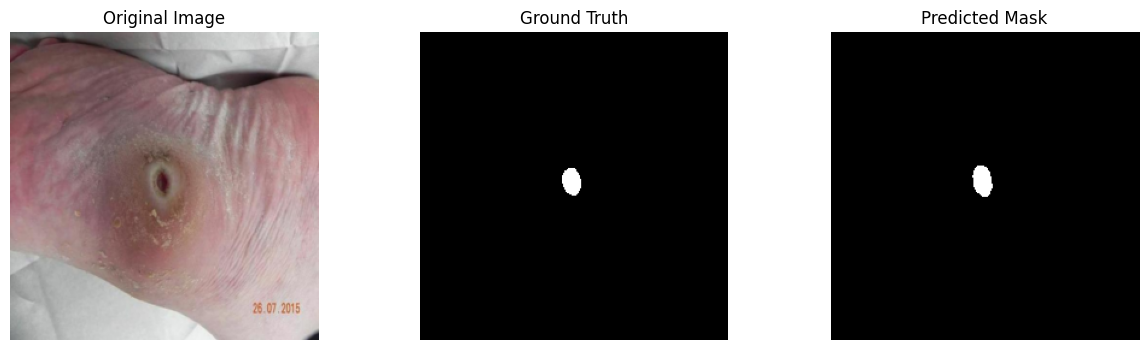

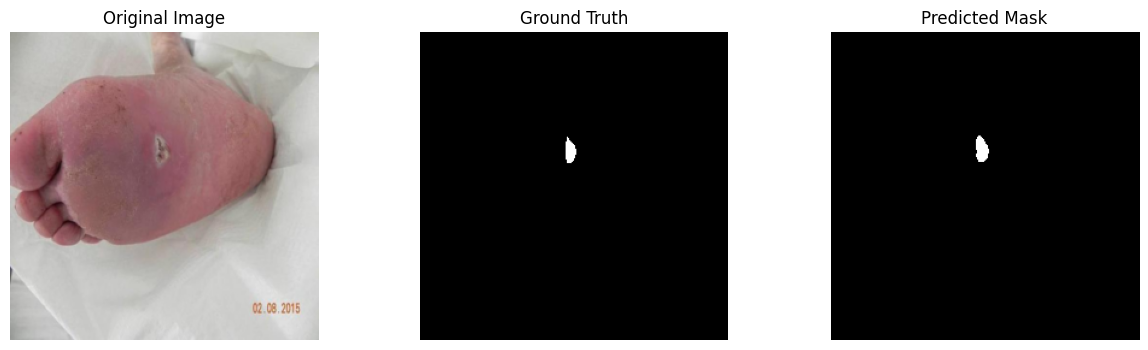

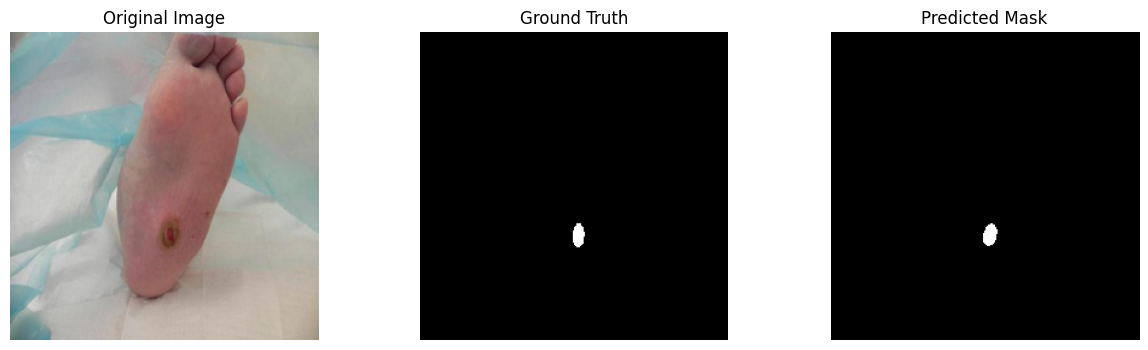

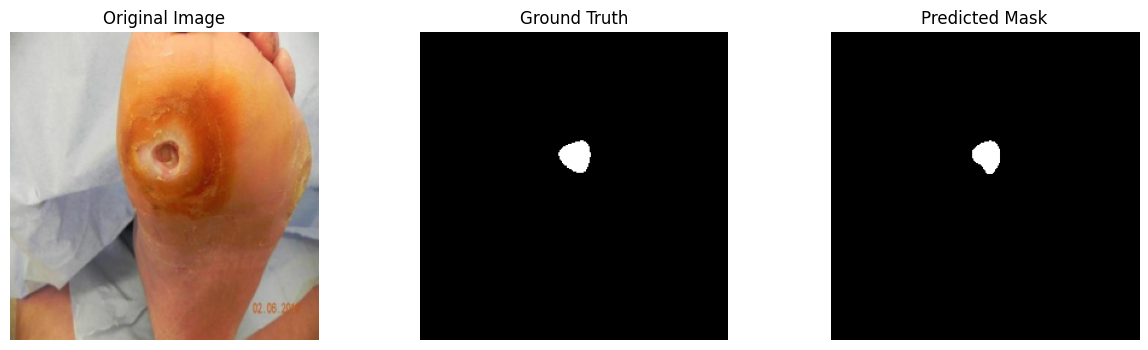

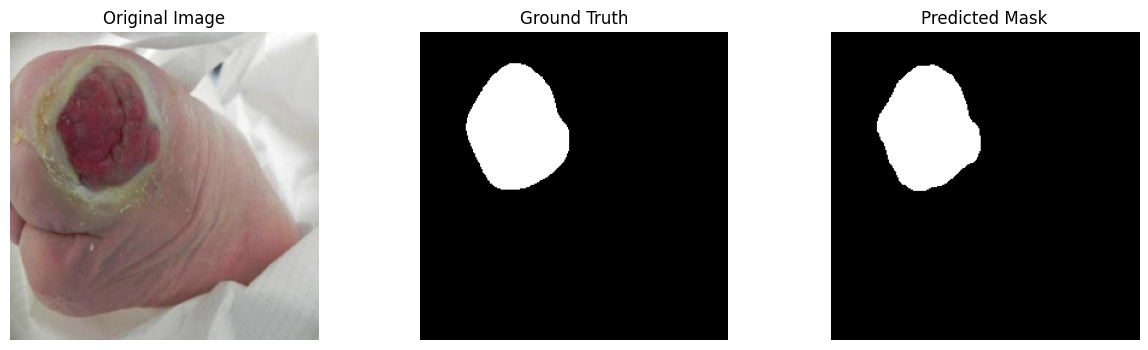

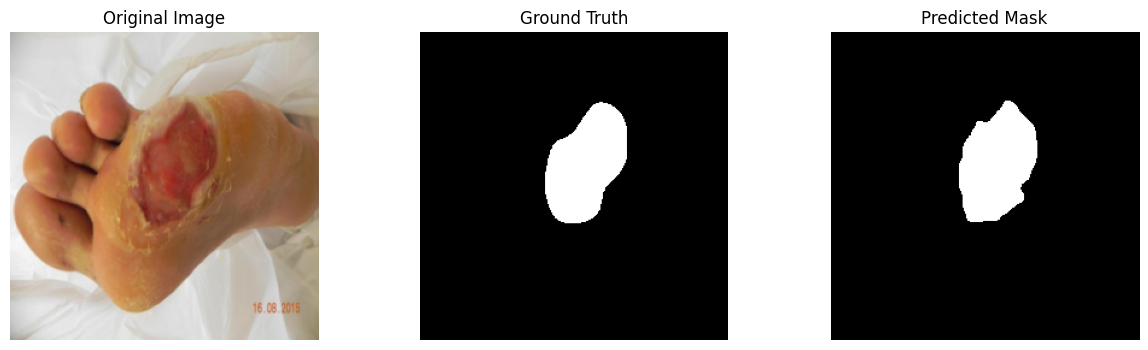

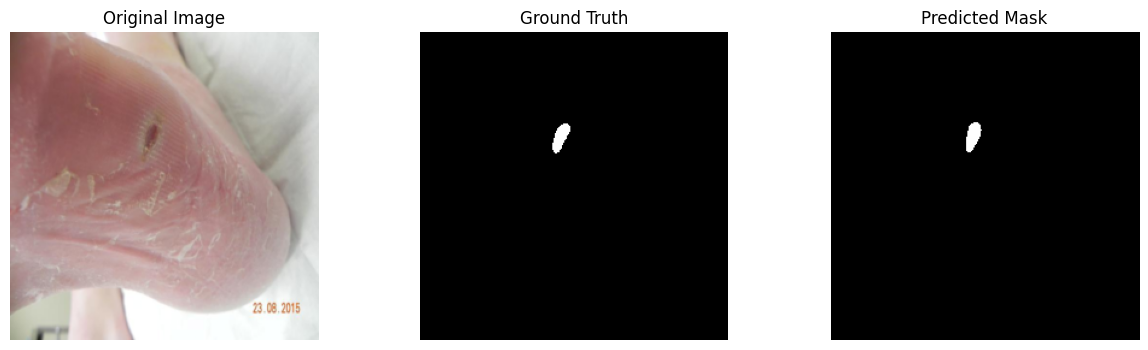

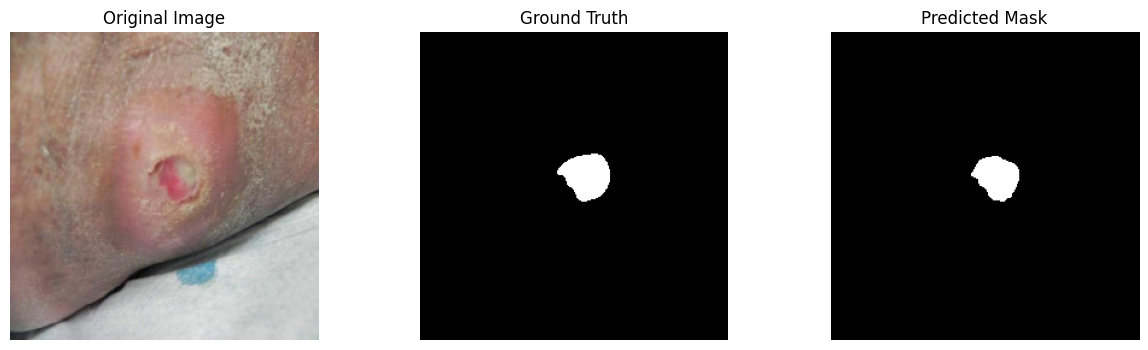

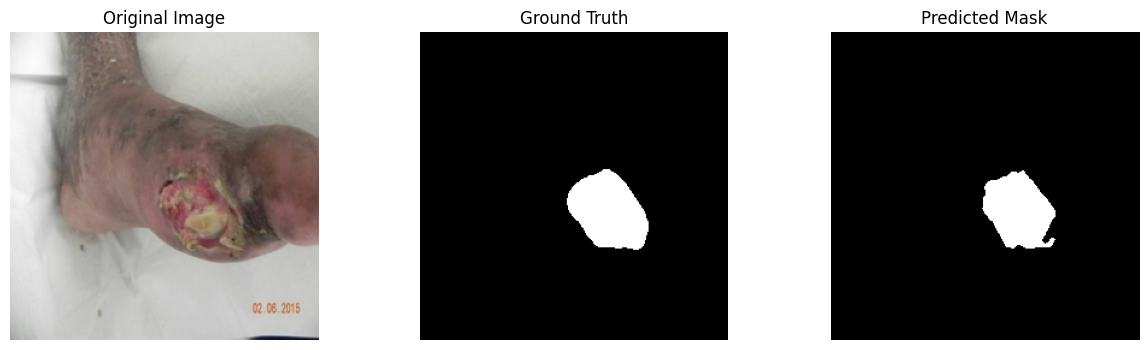

In [ ]:

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    """
    img_tensor: [3, H, W] normalized
    returns:    [3, H, W] in [0,1] for visualization
    """
    mean = IMAGENET_MEAN[:, None, None]
    std = IMAGENET_STD[:, None, None]
    img = img_tensor * std + mean
    return img.clamp(0, 1)

# Ensure model is in evaluation mode and on the correct device
model.eval()
model.to(device)

all_y_true = []
all_y_pred = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        all_y_true.append(masks)
        all_y_pred.append(preds)
Y_val_concatenated = torch.cat(all_y_true, dim=0)
y_pred_val_concatenated = torch.cat(all_y_pred, dim=0)

# Convert raw predictions to binary masks
preds_binary = (y_pred_val_concatenated > 0.5).float().cpu().numpy()

def show_prediction(index=0):
    plt.figure(figsize=(15, 4))

    # ----------------------------
    # Original Image
    # ----------------------------
    img = X_val[index]                  # [3, H, W]
    img = denormalize(img)
    img_np = img.permute(1, 2, 0).cpu().numpy()   # -> [H, W, 3]

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")

    # ----------------------------
    # Ground Truth Mask
    # ----------------------------
    mask = Y_val[index]                 # [1, H, W]
    mask_np = mask.squeeze().cpu().numpy()  # -> [H, W]

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # ----------------------------
    # Predicted Mask
    pred_np = preds_binary[index].squeeze()     # -> [H, W]

    plt.subplot(1, 3, 3)
    plt.imshow(pred_np, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()


# Show 3 predictions
for i in range(10):
    show_prediction(i)


In [ ]:
best_epoch_data = hist_df[hist_df['epoch'] == early_stopping.best_epoch]
final_val_dice = best_epoch_data['val_dice'].values[0]
final_val_iou = best_epoch_data['val_iou'].values[0]

print(f"\nFinal Validation Dice Score (from best epoch {early_stopping.best_epoch}): {final_val_dice:.4f}")
print(f"Final Validation IoU Score (from best epoch {early_stopping.best_epoch}): {final_val_iou:.4f}")


Final Validation Dice Score (from best epoch 25): 0.8857
Final Validation IoU Score (from best epoch 25): 0.7980


## Evaluate on Test Data

In [ ]:
# Load test data
X_test, Y_test = load_images_and_masks(paths.get("Test Images"), paths.get("Test Masks"))

# Create DataLoader for test data
test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Test samples: {X_test.shape[0]}")

# Evaluate on test set
model.eval()
test_dice_sum = 0.0
test_iou_sum = 0.0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)

        test_dice_sum += dice_coef(masks, preds, threshold=0.5)
        test_iou_sum += iou_score(masks, preds, threshold=0.5)

test_dice = test_dice_sum / max(1, len(test_loader))
test_iou = test_iou_sum / max(1, len(test_loader))

print(f"\nTest Dice Score: {test_dice:.4f}")
print(f"Test IoU Score: {test_iou:.4f}")


# Log test metrics to MLflow
with mlflow.start_run() as run:
    mlflow.log_metric("final_test_dice", test_dice)
    mlflow.log_metric("final_test_iou", test_iou)
    print(f"Test metrics logged to MLflow run: {run.info.run_id}")

Test samples: 712

Test Dice Score: 0.8658
Test IoU Score: 0.7734
Test metrics logged to MLflow run: b558ec145e66475e90718add618368ce


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import mlflow
import os

# ----------------------- 1. Testdaten vorbereiten -----------------------


print(f"Test samples: {X_test.shape[0]}")

# ----------------------- 2. Evaluation auf dem Test-Set -----------------------
model.eval()
model.to(device)

test_dice_sum = 0.0
test_iou_sum = 0.0

# Wir speichern die Scores für jedes einzelne Bild für die spätere Analyse
individual_dice_scores = []

with torch.no_grad():
    for i in range(len(X_test)):
        # Einzelnes Bild für Metrik-Analyse
        img = X_test[i].unsqueeze(0).to(device)
        mask = Y_test[i].unsqueeze(0).to(device)

        logits = model(img)
        probs = torch.sigmoid(logits) # Wichtig: Umwandlung in Wahrscheinlichkeiten

        # Metriken berechnen
        d_score = dice_coef(mask, probs, threshold=0.5)
        i_score = iou_score(mask, probs, threshold=0.5)

        test_dice_sum += d_score
        test_iou_sum += i_score

        # Speichern für Worst-Case Analyse
        individual_dice_scores.append((i, d_score))

# Durchschnittswerte berechnen
test_dice = test_dice_sum / max(1, len(X_test))
test_iou = test_iou_sum / max(1, len(X_test))

print(f"\nDurchschnittlicher Test Dice Score: {test_dice:.4f}")
print(f"Durchschnittlicher Test IoU Score: {test_iou:.4f}")

# ----------------------- 3. MLflow Logging -----------------------
# Wir loggen die finalen Test-Werte (essenziell für wissenschaftliche Arbeiten)
with mlflow.start_run(run_name="Final_Test_Evaluation") as run:
    mlflow.log_metric("final_test_dice", test_dice)
    mlflow.log_metric("final_test_iou", test_iou)
    print(f"Test-Metriken in MLflow geloggt unter Run: {run.info.run_id}")

# ----------------------- 4. Worst-Case Analyse -----------------------
# Sortierung: Schlechteste Scores (niedrigster Dice) zuerst
individual_dice_scores.sort(key=lambda x: x[1])

# Die 10 schlechtesten Indizes und deren Scores extrahieren
worst_results = individual_dice_scores[:30]

# ----------------------- 5. Visualisierung der Fehler -----------------------
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    mean = IMAGENET_MEAN[:, None, None]
    std = IMAGENET_STD[:, None, None]
    img = img_tensor * std + mean
    return img.clamp(0, 1)

def show_worst_prediction(index, score):
    plt.figure(figsize=(15, 4))

    # Original Image (Test Set)
    img = denormalize(X_test[index])
    img_np = img.permute(1, 2, 0).cpu().numpy()

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title(f"Test Image Index: {index}")
    plt.axis("off")

    # Ground Truth
    mask_np = Y_test[index].squeeze().cpu().numpy()
    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap='gray')
    plt.title("Ground Truth (Label)")
    plt.axis("off")

    # Prediction
    model.eval()
    with torch.no_grad():
        logits = model(X_test[index].unsqueeze(0).to(device))
        pred_probs = torch.sigmoid(logits)
        pred_np = (pred_probs > 0.5).float().squeeze().cpu().numpy()

    plt.subplot(1, 3, 3)
    plt.imshow(pred_np, cmap='gray')
    plt.title(f"Prediction (Dice: {score:.4f})")
    plt.axis("off")

    plt.show()

# Anzeige der 10 schlechtesten Ergebnisse
print("\nAnalysiere die 10 schwierigsten Fälle (niedrigster Dice):")
for idx, score in worst_results:
    show_worst_prediction(idx, score)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import zipfile

# -----------------------------------
# Save best weights and zip
# -----------------------------------

output_dir = "./eval_seg"
os.makedirs(output_dir, exist_ok=True)

model_filename = "wound_segmentation_model_best.pth"
save_path = os.path.join(output_dir, model_filename)

# Falls das Modell bereits im Training gespeichert wurde, wird hier nur erneut gespeichert
torch.save(model.state_dict(), save_path)
print(f"Model saved at: {save_path}")

zip_path = os.path.join(output_dir, "wound_segmentation_model_best.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(save_path, arcname=model_filename)

print(f"Model zipped at: {zip_path}")


Model saved at: ./eval_seg/wound_segmentation_model_best.pth
Model zipped at: ./eval_seg/wound_segmentation_model_best.zip


In [ ]:
# Export Torch_Script
import torch
import os

def export_torchscript_script(model, out_path: str, device: str = "cpu"):
    model = model.to(device)
    model.eval()

    scripted = torch.jit.script(model)
    scripted.save(out_path)
    return out_path

# After training, after early_stopping.restore(model):
out_dir = "./eval_seg"
os.makedirs(out_dir, exist_ok=True)

ts_path = os.path.join(out_dir, "wound_segmentation_model_best_scripted.pt")
export_torchscript_script(model, ts_path, device="cpu")
print("Saved TorchScript:", ts_path)

Saved TorchScript: ./eval_seg/wound_segmentation_model_best_scripted.pt


In [ ]:
import os, time, socket
from google.colab import output

drive_mlruns_path = "/content/drive/MyDrive/mlruns"
os.makedirs(drive_mlruns_path, exist_ok=True)

!pkill -f "mlflow (ui|server)" >/dev/null 2>&1 || true

def get_free_port():
    s = socket.socket()
    s.bind(("127.0.0.1", 0))
    port = s.getsockname()[1]
    s.close()
    return port

port = get_free_port()
print("MLflow port:", port)

!nohup mlflow server \
  --backend-store-uri file:{drive_mlruns_path} \
  --default-artifact-root file:{drive_mlruns_path} \
  --host 0.0.0.0 \
  --port {port} \
  --allowed-hosts "*" \
  --cors-allowed-origins "*" \
  --x-frame-options NONE \
  > /content/mlflow_ui.log 2>&1 &

def wait_for_port(port, host="127.0.0.1", timeout_s=25):
    start = time.time()
    while time.time() - start < timeout_s:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.settimeout(1)
            if s.connect_ex((host, port)) == 0:
                return True
        time.sleep(0.5)
    return False

if not wait_for_port(port):
    print("Server nicht erreichbar, Log Ausgabe")
    !tail -n 200 /content/mlflow_ui.log
else:
    output.serve_kernel_port_as_iframe(port, height=800)


MLflow port: 50215


<IPython.core.display.Javascript object>